# Titanic 生存預測

1. 讀取資料與初步檢視。
2. 檢查遺漏值與目標類別比例。
3. 類別型資料編碼。
4. 數值型資料遺漏值填補與標準化。
5. 切割訓練集 / 測試集。
6. 使用簡單的 KNN 模型進行分類。
7. 使用 Accuracy、Precision、Recall、F1-score 與 Confusion Matrix 評估模型。


| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 取值 / 內容說明 | 缺漏值 | 建模時的處理建議 |
|---|---|---|---|---|---:|---|
| `PassengerId` | 乘客編號 | `int64` | 識別欄位 | 每位乘客的唯一編號 | 0 | 通常不作為模型特徵，因為只是流水號 |
| `Survived` | 是否生還 | `int64` | 目標欄位 | `0` = 未生還，`1` = 生還 | 0 | 二元分類的預測目標 `y` |
| `Pclass` | 船艙等級 | `int64` | 類別 / 序位特徵 | `1` = 一等艙，`2` = 二等艙，`3` = 三等艙 | 0 | 可視為有順序的類別特徵；可直接使用或轉成 dummy variables |
| `Name` | 乘客姓名 | `object` | 文字欄位 | 乘客完整姓名，通常包含稱謂，例如 Mr., Mrs., Miss. | 0 | 初學範例通常先不使用；進階可萃取稱謂 Title |
| `Sex` | 性別 | `object` | 類別特徵 | `male`、`female` | 0 | 需要進行類別編碼，例如 `pd.get_dummies()` |
| `Age` | 年齡 | `float64` | 數值特徵 | 乘客年齡，部分兒童年齡會有小數 | 177 | 有缺漏值，常用平均數或中位數填補 |
| `SibSp` | 同船的兄弟姊妹 / 配偶人數 | `int64` | 數值特徵 | 表示同船的 siblings / spouses 數量 | 0 | 可直接使用；也可和 `Parch` 合併成家庭人數 |
| `Parch` | 同船的父母 / 子女人數 | `int64` | 數值特徵 | 表示同船的 parents / children 數量 | 0 | 可直接使用；也可和 `SibSp` 合併成家庭人數 |
| `Ticket` | 船票號碼 | `object` | 文字 / 類別欄位 | 船票編號，格式不完全一致 | 0 | 初學範例通常先不使用，因為類別太多且格式複雜 |
| `Fare` | 票價 | `float64` | 數值特徵 | 乘客支付的票價 | 0 | 可直接使用；若使用 KNN、Logistic Regression 等模型，可考慮標準化 |
| `Cabin` | 客艙號碼 | `object` | 類別 / 文字欄位 | 客艙編號，例如 `C85`、`C123` | 687 | 缺漏值非常多，初學範例通常先不使用 |
| `Embarked` | 登船港口 | `object` | 類別特徵 | `C` = Cherbourg，`Q` = Queenstown，`S` = Southampton | 2 | 有少量缺漏值，可用眾數填補後進行類別編碼 |

In [1]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 讀取 Titanic 資料
# 請確認 titanic.csv 和這份 notebook 放在同一個資料夾
data = pd.read_csv("./titanic.csv")

print("資料前 5 筆：")
display(data.head())

print("資料筆數與欄位數：")
print(data.shape)

print("資料基本資訊：")
display(data.info())

資料前 5 筆：


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


資料筆數與欄位數：
(891, 12)
資料基本資訊：
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

Survived 類別數量：


Survived
0    549
1    342
Name: count, dtype: int64

Survived 類別比例：


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

每個欄位的遺漏值數量：


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

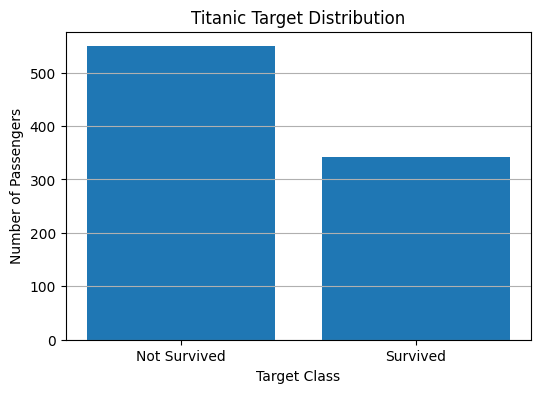

In [2]:
# ============================================================
# 2. 檢查目標欄位與遺漏值
# ============================================================

# Survived 是本範例的目標欄位
# 0 代表未生還，1 代表生還
print("Survived 類別數量：")
display(data["Survived"].value_counts())

print("Survived 類別比例：")
display(data["Survived"].value_counts(normalize=True))

print("每個欄位的遺漏值數量：")
display(data.isna().sum())

# ------------------------------------------------------------
# 視覺化：觀察生還與未生還的人數
# ------------------------------------------------------------
survived_counts = data["Survived"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Survived", "Survived"], survived_counts.values)
plt.xlabel("Target Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Target Distribution")
plt.grid(axis="y")
plt.show()

不同性別的平均生還率：


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

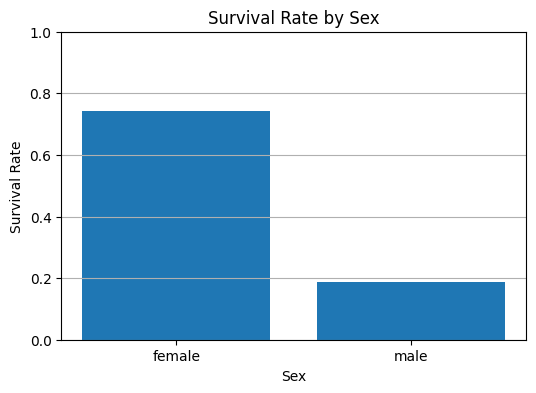

不同艙等的平均生還率：


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

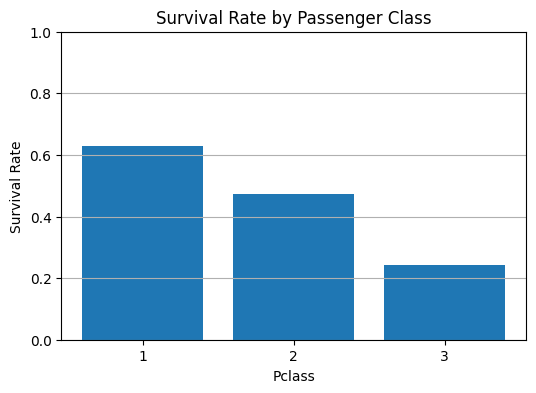

In [3]:
# ============================================================
# 3. 簡單視覺化：觀察 Sex、Pclass 與 Survived 的關係
# ============================================================

# ------------------------------------------------------------
# 依照 Sex 計算平均生還率
# ------------------------------------------------------------
sex_survival_rate = data.groupby("Sex")["Survived"].mean()

print("不同性別的平均生還率：")
display(sex_survival_rate)

plt.figure(figsize=(6, 4))
plt.bar(sex_survival_rate.index, sex_survival_rate.values)
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

# ------------------------------------------------------------
# 依照 Pclass 計算平均生還率
# ------------------------------------------------------------
pclass_survival_rate = data.groupby("Pclass")["Survived"].mean()

print("不同艙等的平均生還率：")
display(pclass_survival_rate)

plt.figure(figsize=(6, 4))
plt.bar(pclass_survival_rate.index.astype(str), pclass_survival_rate.values)
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [4]:
# ============================================================
# 4. 選擇特徵、切割資料集
# ============================================================

# 本範例選擇較容易理解、也常被用來預測 Titanic 生還與否的欄位
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

feature_columns = numeric_features + categorical_features

X = data.loc[:, feature_columns]
y = data["Survived"]

# 先切割資料，再對訓練資料 fit imputer / scaler
# 這樣可以避免把測試集資訊偷看進訓練流程中
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("訓練集筆數：", X_train_raw.shape[0])
print("測試集筆數：", X_test_raw.shape[0])

print("訓練集目標比例：")
display(y_train.value_counts(normalize=True))

print("測試集目標比例：")
display(y_test.value_counts(normalize=True))

訓練集筆數： 712
測試集筆數： 179
訓練集目標比例：


Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

測試集目標比例：


Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [5]:
# ============================================================
# 5. 遺漏值填補、類別編碼與標準化
# ============================================================

# ------------------------------------------------------------
# A. 數值特徵：用中位數填補遺漏值
# ------------------------------------------------------------
numeric_imputer = SimpleImputer(strategy="median")

X_train_numeric = numeric_imputer.fit_transform(X_train_raw.loc[:, numeric_features])
X_test_numeric = numeric_imputer.transform(X_test_raw.loc[:, numeric_features])

X_train_numeric = pd.DataFrame(
    X_train_numeric,
    columns=numeric_features,
    index=X_train_raw.index
)

X_test_numeric = pd.DataFrame(
    X_test_numeric,
    columns=numeric_features,
    index=X_test_raw.index
)

# ------------------------------------------------------------
# B. 數值特徵：標準化
# ------------------------------------------------------------
# KNN 是距離式模型，特徵尺度會影響距離計算，所以這裡使用 StandardScaler
scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

X_train_numeric_scaled = pd.DataFrame(
    X_train_numeric_scaled,
    columns=numeric_features,
    index=X_train_raw.index
)

X_test_numeric_scaled = pd.DataFrame(
    X_test_numeric_scaled,
    columns=numeric_features,
    index=X_test_raw.index
)

# ------------------------------------------------------------
# C. 類別特徵：用最常出現的類別填補遺漏值
# ------------------------------------------------------------
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_categorical = categorical_imputer.fit_transform(X_train_raw.loc[:, categorical_features])
X_test_categorical = categorical_imputer.transform(X_test_raw.loc[:, categorical_features])

X_train_categorical = pd.DataFrame(
    X_train_categorical,
    columns=categorical_features,
    index=X_train_raw.index
)

X_test_categorical = pd.DataFrame(
    X_test_categorical,
    columns=categorical_features,
    index=X_test_raw.index
)

# ------------------------------------------------------------
# D. 類別特徵：One-hot Encoding
# ------------------------------------------------------------
X_train_categorical_encoded = pd.get_dummies(
    X_train_categorical,
    columns=categorical_features,
    drop_first=False
)

X_test_categorical_encoded = pd.get_dummies(
    X_test_categorical,
    columns=categorical_features,
    drop_first=False
)

# 測試集可能缺少某些訓練集出現過的類別欄位
# 因此要把測試集欄位對齊訓練集欄位
X_test_categorical_encoded = X_test_categorical_encoded.reindex(
    columns=X_train_categorical_encoded.columns,
    fill_value=0
)

# ------------------------------------------------------------
# E. 合併處理完成的數值特徵與類別特徵
# ------------------------------------------------------------
X_train_processed = pd.concat(
    [X_train_numeric_scaled, X_train_categorical_encoded],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_numeric_scaled, X_test_categorical_encoded],
    axis=1
)

print("處理後的訓練資料欄位：")
display(X_train_processed.head())

print("處理後的訓練資料大小：")
print(X_train_processed.shape)

處理後的訓練資料欄位：


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
502,-0.090996,-0.486935,-0.467659,-0.482061,False,False,True,True,False,False,True,False
464,-0.090996,-0.486935,-0.467659,-0.474085,False,False,True,False,True,False,False,True
198,-0.090996,-0.486935,-0.467659,-0.479771,False,False,True,True,False,False,True,False
765,1.700215,0.457745,-0.467659,0.850885,True,False,False,True,False,False,False,True
421,-0.636146,-0.486935,-0.467659,-0.480088,False,False,True,False,True,False,True,False


處理後的訓練資料大小：
(712, 12)


In [6]:
# ============================================================
# 6. 建立 KNN 分類模型
# ============================================================

# KNN 是 Module 1 用來示範 train/test split 與 cross validation 的簡單模型
# 這裡用它來預測乘客是否生還

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)

print("前 10 筆預測結果：")
prediction_table = pd.DataFrame()
prediction_table["actual"] = y_test.values[:10]
prediction_table["predicted"] = y_pred[:10]
display(prediction_table)

前 10 筆預測結果：


,actual,predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
5,0,0
6,0,0
7,0,1
8,0,0
9,1,0


代表性評估指標：


,metric,value
0,Accuracy,0.810056
1,Precision,0.818182
2,Recall,0.652174
3,F1-score,0.725806


分類報告：
              precision    recall  f1-score   support

Not Survived       0.81      0.91      0.85       110
    Survived       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



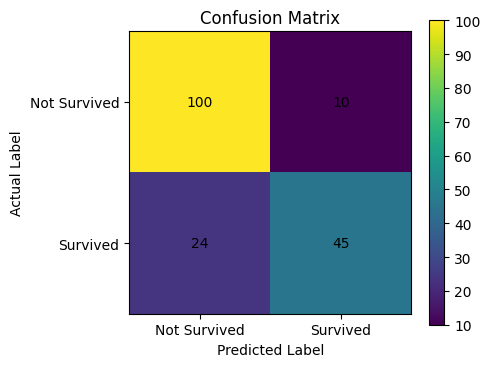

In [7]:
# ============================================================
# 7. 模型評估：Accuracy、Precision、Recall、F1-score、Confusion Matrix
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metric_table = pd.DataFrame()
metric_table["metric"] = ["Accuracy", "Precision", "Recall", "F1-score"]
metric_table["value"] = [accuracy, precision, recall, f1]

print("代表性評估指標：")
display(metric_table)

print("分類報告：")
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])

row_index = 0
while row_index < cm.shape[0]:
    column_index = 0
    while column_index < cm.shape[1]:
        plt.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center"
        )
        column_index = column_index + 1
    row_index = row_index + 1

plt.colorbar() # Confusion Matrix 的顏色圖例
plt.tight_layout()
plt.show()